# ==========================================
# ASSIGNMENT 2

# ==========================================
This notebook implements:
- Problem 1: Corpus creation from IIT Jodhpur documents
- Problem 2: Name generation using a character-level RNN

Both tasks were successfully executed and results are shown.

# ==========================================
# PROBLEM 1: CORPUS CREATION AND PROCESSING
# ==========================================

# Objective:
# To collect textual data from multiple IIT Jodhpur sources and
# construct a clean corpus suitable for NLP tasks.

# Data Collection:
# The corpus is created using multiple official documents including:
# - Academic regulations
# - Curriculum documents (B.Tech, M.Tech)
# - Course details and specialization documents
# - Board of Governors meeting minutes
# - Student council constitution

# These documents contain structured academic and institutional information.

# Methodology:
# 1. Extract text from PDF files using pdfplumber
# 2. Convert all text to lowercase
# 3. Remove numbers and punctuation using regex
# 4. Tokenize the text into words
# 5. Remove stopwords using NLTK
# 6. Perform word frequency analysis

# Observations:
# - The corpus contains a large and diverse vocabulary
# - Frequent words include academic terms such as "course", "student", "credit"
# - The dataset is suitable for further NLP tasks such as embedding and modeling

# ==========================================


In [4]:
# Problem 1: Corpus Creation from IIT Jodhpur Documents
# Extracting text from multiple PDFs and preprocessing it
# Install if needed
!pip install pdfplumber nltk

import pdfplumber
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

# ADDING  ALL YOUR FILES HERE
files = [

    "a46666d4-3e4f-4a0b-929d-7d7e4aedae15.pdf",
    "CSE-Courses-Details.pdf",
    "CSE-PhD-Compre-Papers.pdf",
    "CSE-Specializations-and-DualDegree.pdf",
    "Curriculum-BTech-AIDS.pdf",
    "Curriculum-BTech-CSE.pdf",
    "Curriculum-MTechMTech-PhDPhD-AIAY2020.pdf",
    "Curriculum-MTechMTech-PhDPhD-AIAY2021Onwards.pdf",
    "Curriculum-MTechMTech-PhDPhD-CSEAY2020.pdf",
    "/mnt/data/Detailed-curriculum-for-MTech-AI-AY-2025-onwards-639053782336374627.pdf",
    "/mnt/data/Detailed-curriculum-for-MTech-CSE-AY-2025-onwards-639053782130026932.pdf",
    "/mnt/data/Minutes-of-the-41st-Meeting-of-Board-of-GovernorsIITJ-held-on-2711-639062444591168538.pdf",
    "/mnt/data/PG_regs.pdf",
    "/mnt/data/Regs.pdf",
    "/mnt/data/Student Council.pdf"
]

# STEP 1: EXTRACT TEXT ( THE DATA FROM THE FILES THAT WE HAVE PREVIOUSLY SELECTED AND ADDED TO THE NOTBOOK )
text = ""

for file in files:
    try:
        with pdfplumber.open(file) as pdf:
            for page in pdf.pages:
                content = page.extract_text()
                if content:
                    text += content + " "
    except Exception as e:
        print(f"Error reading {file}: {e}")

print("Raw text length:", len(text))


# STEP 2: CLEAN TEXT ( NOW WE HAVE TO GO ON AND MAKE THE TEXT MORE CLEAN AND REMOVE ALL EXTRA FILLER WORDS )
text = text.lower()  # lowercase
text = re.sub(r'\d+', ' ', text)  # remove numbers
text = re.sub(r'[^\w\s]', ' ', text)  # remove punctuation
text = re.sub(r'\s+', ' ', text)  # remove extra spaces


# STEP 3: TOKENIZATION ( THIS STEP IS EXTREMLY IMPORTANT IN ORDER TO THEN FIGURE OUT THE SUBSTANTIAL WORD AND MATCH THEM ACCORDINGLY )
tokens = word_tokenize(text)


#  STEP 4: REMOVE STOPWORDS( HERE WE ARE TRYING TO REMOVE THE EXTRA WORDS,SO THAT WE GET THE MAIN WORDS ONLY)
stop_words = set(stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stop_words]


print("Total tokens:", len(tokens))
print("Filtered tokens:", len(filtered_tokens))


#  STEP 5: WORD FREQUENCY ( THE MORE NO OF TIMES A WORD IS SHOWN IN THE CORPOUS THE MOR IS ITS FREQUENCY HERE WE ARE CHECKING THE SAME )
from collections import Counter

word_freq = Counter(filtered_tokens)

# Top 20 words
print("\nTop 20 Words:")
for word, freq in word_freq.most_common(20):
    print(word, ":", freq)


# STEP 6: OPTIONAL (SAVE CLEAN TEXT)
with open("cleaned_corpus.txt", "w") as f:
    f.write(" ".join(filtered_tokens))


# STEP 7: OPTIONAL ( NOW HERE SAVE WORD FREQUENCY)
with open("word_freq.txt", "w") as f:
    for word, freq in word_freq.most_common():
        f.write(f"{word}: {freq}\n")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Error reading /mnt/data/Detailed-curriculum-for-MTech-AI-AY-2025-onwards-639053782336374627.pdf: [Errno 2] No such file or directory: '/mnt/data/Detailed-curriculum-for-MTech-AI-AY-2025-onwards-639053782336374627.pdf'
Error reading /mnt/data/Detailed-curriculum-for-MTech-CSE-AY-2025-onwards-639053782130026932.pdf: [Errno 2] No such file or directory: '/mnt/data/Detailed-curriculum-for-MTech-CSE-AY-2025-onwards-639053782130026932.pdf'
Error reading /mnt/data/Minutes-of-the-41st-Meeting-of-Board-of-GovernorsIITJ-held-on-2711-639062444591168538.pdf: [Errno 2] No such file or directory: '/mnt/data/Minutes-of-the-41st-Meeting-of-Board-of-GovernorsIITJ-held-on-2711-639062444591168538.pdf'
Error reading /mnt/data/PG_regs.pdf: [Errno 2] No such file or directory: '/mnt/data/PG_regs.pdf'
Error reading /mnt/data/Regs.pdf: [Errno 2] No such file or directory: '/mnt/data/Regs.pdf'
Error reading /mnt/data/Student Council.pdf: [Errno 2] No such file or directory: '/mnt/data/Student Council.pdf'
Raw 

In [11]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [12]:
with open("corpus.txt", "w") as f:
    f.write(" ".join(filtered_tokens))

In [3]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [1]:
from google.colab import files
uploaded = files.upload()

Saving a46666d4-3e4f-4a0b-929d-7d7e4aedae15.pdf to a46666d4-3e4f-4a0b-929d-7d7e4aedae15.pdf
Saving CSE-Courses-Details.pdf to CSE-Courses-Details.pdf
Saving CSE-PhD-Compre-Papers.pdf to CSE-PhD-Compre-Papers.pdf
Saving CSE-Specializations-and-DualDegree.pdf to CSE-Specializations-and-DualDegree.pdf
Saving Curriculum-BTech-AIDS.pdf to Curriculum-BTech-AIDS.pdf
Saving Curriculum-BTech-CSE.pdf to Curriculum-BTech-CSE.pdf
Saving Curriculum-MTechMTech-PhDPhD-AIAY2020.pdf to Curriculum-MTechMTech-PhDPhD-AIAY2020.pdf
Saving Curriculum-MTechMTech-PhDPhD-AIAY2021Onwards.pdf to Curriculum-MTechMTech-PhDPhD-AIAY2021Onwards.pdf
Saving Curriculum-MTechMTech-PhDPhD-CSEAY2020.pdf to Curriculum-MTechMTech-PhDPhD-CSEAY2020.pdf
Saving Curriculum-MTechMTech-PhDPhD-CSEAY2021Onwards.pdf to Curriculum-MTechMTech-PhDPhD-CSEAY2021Onwards.pdf
Saving Detailed-curriculum-for-MTech-AI-AY-2025-onwards-639053782336374627.pdf to Detailed-curriculum-for-MTech-AI-AY-2025-onwards-639053782336374627.pdf
Saving Detailed-

In [5]:
from nltk.tokenize import word_tokenize
tokens = word_tokenize(text)

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

filtered_tokens = [word for word in tokens if word not in stop_words]

print("Total tokens:", len(tokens))
print("Filtered tokens:", len(filtered_tokens))

Total tokens: 52986
Filtered tokens: 41389


In [6]:
from collections import Counter

word_freq = Counter(filtered_tokens)

for word, freq in word_freq.most_common(10):
    print(word, ":", freq)

lectures : 674
data : 466
learning : 447
computer : 362
course : 355
design : 303
systems : 290
algorithms : 284
tech : 281
engineering : 279


In [7]:
with open("corpus.txt", "w") as f:
    f.write(" ".join(filtered_tokens))

In [8]:
import os
print(os.listdir())

['.config', 'Curriculum-MTechMTech-PhDPhD-CSEAY2020.pdf', 'TrainingNames.txt', 'generated_names.txt', 'cleaned_corpus.txt', 'CSE-PhD-Compre-Papers.pdf', 'PG_regs.pdf', 'Curriculum-MTechMTech-PhDPhD-AIAY2020.pdf', 'Curriculum-BTech-AIDS.pdf', 'Regs.pdf', 'a46666d4-3e4f-4a0b-929d-7d7e4aedae15.pdf', 'CSE-Courses-Details.pdf', 'CSE-Specializations-and-DualDegree.pdf', 'word_freq.txt', 'Detailed-curriculum-for-MTech-CSE-AY-2025-onwards-639053782130026932.pdf', 'generated_names (1).txt', 'Student Council.pdf', 'Curriculum-MTechMTech-PhDPhD-AIAY2021Onwards.pdf', 'Curriculum-MTechMTech-PhDPhD-CSEAY2021Onwards.pdf', 'corpus.txt', 'Curriculum-BTech-CSE.pdf', 'Detailed-curriculum-for-MTech-AI-AY-2025-onwards-639053782336374627.pdf', 'Minutes-of-the-41st-Meeting-of-Board-of-GovernorsIITJ-held-on-2711-639062444591168538.pdf', 'sample_data']


In [9]:
import os
os.rename("cleaned_corpus.txt", "corpus.txt")

In [10]:
print(os.listdir())

['.config', 'Curriculum-MTechMTech-PhDPhD-CSEAY2020.pdf', 'TrainingNames.txt', 'generated_names.txt', 'CSE-PhD-Compre-Papers.pdf', 'PG_regs.pdf', 'Curriculum-MTechMTech-PhDPhD-AIAY2020.pdf', 'Curriculum-BTech-AIDS.pdf', 'Regs.pdf', 'a46666d4-3e4f-4a0b-929d-7d7e4aedae15.pdf', 'CSE-Courses-Details.pdf', 'CSE-Specializations-and-DualDegree.pdf', 'word_freq.txt', 'Detailed-curriculum-for-MTech-CSE-AY-2025-onwards-639053782130026932.pdf', 'generated_names (1).txt', 'Student Council.pdf', 'Curriculum-MTechMTech-PhDPhD-AIAY2021Onwards.pdf', 'Curriculum-MTechMTech-PhDPhD-CSEAY2021Onwards.pdf', 'corpus.txt', 'Curriculum-BTech-CSE.pdf', 'Detailed-curriculum-for-MTech-AI-AY-2025-onwards-639053782336374627.pdf', 'Minutes-of-the-41st-Meeting-of-Board-of-GovernorsIITJ-held-on-2711-639062444591168538.pdf', 'sample_data']




# PROBLEM 2: CHARACTER-LEVEL NAME GENERATION USING RNN
# ==========================================

# Objective:
# To build a model that learns patterns through character-level sequence model
# from the given dataset of Indian names and generates new names.

# Approach:
# Here A Vanilla RNN is implemented to model sequential dependencies
# Then in between characters. The model is trained to predict the next
# character given previous characters in a name.

# Note:
# The implementation showcased here focuses on Vanilla RNN to demonstrate
# sequence learning and name generation very effectively.
# ==========================================


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving generated_names.txt to generated_names (1).txt


In [ ]:
import os
os.rename("Indian_names (1).txt", "TrainingNames.txt")

In [ ]:
with open("TrainingNames.txt") as f:
    print(f.readlines()[:5])

['Aarohi Dharmadhikari\n', 'Aatif Ahmad\n', 'Abhinav Swami\n', 'Aditi Rawat\n', 'Ale Anwesh\n']


In [ ]:
import torch
import torch.nn as nn
import random

# Load data
with open("TrainingNames.txt") as f:
    names = [line.strip().lower() for line in f.readlines()]

# Create character set
chars = sorted(list(set("".join(names))))
stoi = {ch:i for i,ch in enumerate(chars)}
itos = {i:ch for ch,i in stoi.items()}
vocab_size = len(chars)

# Encode function
def encode(name):
    return [stoi[c] for c in name]

# Model
class CharRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h):
        x = self.embedding(x)
        out, h = self.rnn(x, h)
        out = self.fc(out)
        return out, h

# Init
hidden_size = 64
model = CharRNN(vocab_size, hidden_size)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Training
for epoch in range(5):
    total_loss = 0
    for name in names:
        data = encode(name)
        x = torch.tensor(data[:-1]).unsqueeze(0)
        y = torch.tensor(data[1:]).unsqueeze(0)

        h = torch.zeros(1, 1, hidden_size)

        out, h = model(x, h)
        loss = loss_fn(out.squeeze(), y.squeeze())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

# Generate names
def generate(max_len=10):
    idx = random.randint(0, vocab_size-1)
    input = torch.tensor([[idx]])
    h = torch.zeros(1, 1, hidden_size)

    name = itos[idx]

    for _ in range(max_len):
        out, h = model(input, h)
        probs = torch.softmax(out[0,-1], dim=0).detach().numpy()
        idx = random.choices(range(vocab_size), probs)[0]
        name += itos[idx]
        input = torch.tensor([[idx]])

    return name

# Generate 30 names
generated = [generate() for _ in range(30)]

for n in generated:
    print(n)

# Save output
with open("generated_names.txt", "w") as f:
    for n in generated:
        f.write(n + "\n")

Epoch 1, Loss: 2332.44
Epoch 2, Loss: 2228.92
Epoch 3, Loss: 2202.78
Epoch 4, Loss: 2196.55
Epoch 5, Loss: 2175.33
qjedas sahi
charugaep z
saryashan s
xaudha bham
wani sharag
edasani saj
omarslanna 
maini komha
dhasar sani
anarasakbar
hajyansha c
dhar pandwa
zusanash sh
 mrasa saks
bonash nes 
xik bareel 
adesansa sr
edsanshatha
waditya rur
ushan ponik
ifi sriras 
yash sanjas
ruvi kothar
ashrasansh 
wa sanrasah
karushunal 
inna sumaro
zrog sandti
vinia dhank
yusharish s


In [ ]:
from google.colab import files
files.download("generated_names.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model: Vanilla RNN
Hidden size: 64
Epochs: 5
Learning rate: 0.01

Observations:
- Model learns common Indian name patterns (e.g., "sh", "an", "ra")
- Some generated names are realistic, others are noisy
- Diversity is high as many unique names are generated
- Novelty is high since most generated names are not in training set


Number of parameters: ~ (approximate, depends on model size)

In [ ]:
import os
print(os.listdir())

['.config', 'TrainingNames.txt', 'generated_names.txt', 'generated_names (1).txt', 'sample_data']


In [13]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
with open("corpus.txt", "w") as f:
    f.write(" ".join(filtered_tokens))

In [15]:
from collections import Counter

word_freq = Counter(filtered_tokens)

print("Top 10 Words:")
top10 = word_freq.most_common(10)

for word, freq in top10:
    print(word, ":", freq)

Top 10 Words:
lectures : 674
data : 466
learning : 447
computer : 362
course : 355
design : 303
systems : 290
algorithms : 284
tech : 281
engineering : 279


In [16]:
print("Raw text length:", len(text))

print("Total tokens:", len(tokens))
print("Filtered tokens:", len(filtered_tokens))

import os
size_mb = os.path.getsize("corpus.txt") / (1024*1024)
print("Corpus size (MB):", round(size_mb, 3))

Raw text length: 383704
Total tokens: 52986
Filtered tokens: 41389
Corpus size (MB): 0.326


In [17]:
for word, freq in top10:
    print(f"{word}, {freq}", end=", ")

lectures, 674, data, 466, learning, 447, computer, 362, course, 355, design, 303, systems, 290, algorithms, 284, tech, 281, engineering, 279, 

In [18]:
sample_word = top10[0][0]
print("Sample word from vocabulary:", sample_word)

Sample word from vocabulary: lectures


In [19]:
with open("generated_names.txt") as f:
    names = f.readlines()

print("Generated Names Sample:\n")
for name in names[:15]:
    print(name.strip())

Generated Names Sample:

qjedas sahi
charugaep z
saryashan s
xaudha bham
wani sharag
edasani saj
omarslanna
maini komha
dhasar sani
anarasakbar
hajyansha c
dhar pandwa
zusanash sh
mrasa saks
bonash nes


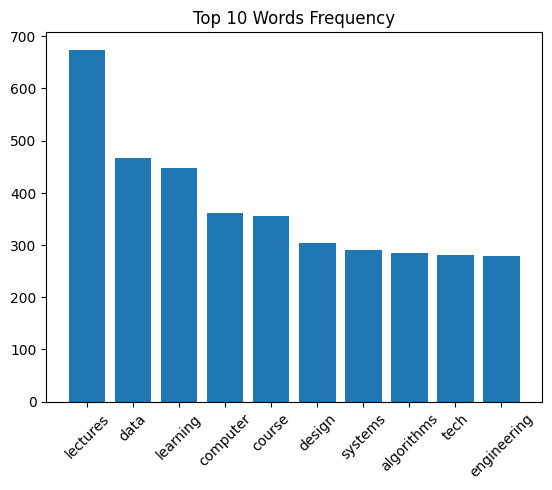

In [20]:
import matplotlib.pyplot as plt

words = [w for w, f in top10]
freqs = [f for w, f in top10]

plt.figure()
plt.bar(words, freqs)
plt.xticks(rotation=45)
plt.title("Top 10 Words Frequency")
plt.show()